# Transformações de Variáveis para Normalização

Este notebook aplica e compara diferentes transformações nas variáveis do dataset de treino, com objetivo de:
- Melhorar a normalidade das distribuições
- Aumentar o poder discriminativo entre os grupos
- Preparar variáveis para modelos de machine learning

**Transformações testadas:**
1. **Log** (natural e log10) - para distribuições assimétricas à direita
2. **Square Root (√)** - para dados positivos com assimetria moderada
3. **Cube Root (∛)** - similar à raiz quadrada, mas aceita valores negativos
4. **Box-Cox** - transformação ótima baseada em máxima verossimilhança
5. **Yeo-Johnson** - similar ao Box-Cox, mas aceita zeros e negativos
6. **Reciprocal (1/x)** - para distribuições muito assimétricas
7. **Square (x²)** - para distribuições assimétricas à esquerda
8. **Exponential** - transformação exponencial

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, mannwhitneyu, boxcox, yeojohnson
from sklearn.preprocessing import PowerTransformer
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.6f' % x)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 1. Carregar Dados e Resultados das Análises Anteriores

In [2]:
# Carregar dataset de treino
df_treino = pd.read_csv('../data/processed/df_treino.csv')

# Carregar resultados das análises anteriores
df_parametric = pd.read_csv('../data/processed/parametric_analysis_results.csv')
df_nonparametric = pd.read_csv('../data/processed/nonparametric_analysis_results.csv')

print(f"Dataset de treino: {df_treino.shape}")
print(f"\nResultados análise paramétrica: {df_parametric.shape}")
print(f"Resultados análise não-paramétrica: {df_nonparametric.shape}")

# Identificar variáveis e target
numeric_cols = df_treino.select_dtypes(include=[np.number]).columns.tolist()
target_col = 'Is Laundering' if 'Is Laundering' in df_treino.columns else None

if target_col and target_col in numeric_cols:
    feature_cols = [col for col in numeric_cols if col != target_col]
else:
    feature_cols = numeric_cols.copy()

print(f"\nTarget: {target_col}")
print(f"Features para transformação: {len(feature_cols)}")
print(f"Variáveis: {feature_cols}")

Dataset de treino: (25001186, 21)

Resultados análise paramétrica: (6, 17)
Resultados análise não-paramétrica: (6, 29)

Target: Is Laundering
Features para transformação: 6
Variáveis: ['From Bank', 'To Bank', 'Amount Received', 'Amount Paid', 'Bank ID', 'Bank ID_To']


## 2. Funções de Transformação

Definindo funções para aplicar diferentes tipos de transformações.

In [3]:
def apply_transformations(data, variable_name):
    """
    Aplica múltiplas transformações em uma variável.
    
    Returns:
    --------
    dict : Dicionário com todas as transformações possíveis
    """
    # Remover NaN
    clean_data = data.dropna()
    
    transformations = {}
    transformations['original'] = clean_data
    
    # Log transformations (requer valores > 0)
    if (clean_data > 0).all():
        transformations['log'] = np.log(clean_data)
        transformations['log10'] = np.log10(clean_data)
        transformations['log1p'] = np.log1p(clean_data)  # log(1+x)
    
    # Square root (requer valores >= 0)
    if (clean_data >= 0).all():
        transformations['sqrt'] = np.sqrt(clean_data)
    
    # Cube root (aceita negativos)
    transformations['cbrt'] = np.cbrt(clean_data)
    
    # Square
    transformations['square'] = clean_data ** 2
    
    # Cube
    transformations['cube'] = clean_data ** 3
    
    # Reciprocal (requer valores != 0)
    if not (clean_data == 0).any():
        transformations['reciprocal'] = 1 / clean_data
    
    # Box-Cox (requer valores > 0)
    if (clean_data > 0).all() and len(clean_data) > 1:
        try:
            transformed, lambda_param = boxcox(clean_data)
            transformations['boxcox'] = pd.Series(transformed, index=clean_data.index)
            transformations['boxcox_lambda'] = lambda_param
        except:
            pass
    
    # Yeo-Johnson (aceita qualquer valor)
    if len(clean_data) > 1:
        try:
            pt = PowerTransformer(method='yeo-johnson', standardize=False)
            transformed = pt.fit_transform(clean_data.values.reshape(-1, 1)).flatten()
            transformations['yeojohnson'] = pd.Series(transformed, index=clean_data.index)
        except:
            pass
    
    # Exponential (cuidado com overflow)
    try:
        # Normalizar antes para evitar overflow
        normalized = (clean_data - clean_data.min()) / (clean_data.max() - clean_data.min())
        transformations['exp'] = np.exp(normalized)
    except:
        pass
    
    return transformations

print("Funções de transformação definidas!")

Funções de transformação definidas!


## 3. Função de Avaliação de Transformações

Função para avaliar a qualidade de cada transformação usando múltiplos critérios.

In [7]:
def evaluate_transformation(transformed_data, target_data, transformation_name, sample_size=5000):
    """
    Avalia a qualidade de uma transformação usando múltiplos critérios.
    
    Critérios:
    1. Normalidade (Shapiro-Wilk p-value)
    2. Poder discriminativo (Mann-Whitney p-value)
    3. Assimetria (skewness)
    4. Curtose (kurtosis)
    """
    # Usar amostra se dataset for muito grande
    if len(transformed_data) > sample_size:
        sample_indices = transformed_data.sample(n=sample_size, random_state=42).index
        sample_data = transformed_data.loc[sample_indices]
        sample_target = target_data.loc[sample_indices]
    else:
        sample_data = transformed_data
        sample_target = target_data
    
    results = {
        'transformation': transformation_name,
        'n_obs': len(transformed_data)
    }
    
    # 1. Teste de normalidade (Shapiro-Wilk)
    try:
        shapiro_stat, shapiro_p = shapiro(sample_data)
        results['shapiro_pvalue'] = shapiro_p
        results['shapiro_stat'] = shapiro_stat
    except:
        results['shapiro_pvalue'] = np.nan
        results['shapiro_stat'] = np.nan
    
    # 2. Teste de Mann-Whitney (poder discriminativo)
    try:
        group_0 = transformed_data[target_data == 0].dropna()
        group_1 = transformed_data[target_data == 1].dropna()
        
        if len(group_0) > 100 and len(group_1) > 100:
            # Amostra para o teste se necessário
            if len(group_0) > 5000:
                group_0_sample = group_0.sample(n=5000, random_state=42)
            else:
                group_0_sample = group_0
                
            if len(group_1) > 5000:
                group_1_sample = group_1.sample(n=5000, random_state=42)
            else:
                group_1_sample = group_1
            
            mw_stat, mw_p = mannwhitneyu(group_0_sample, group_1_sample, alternative='two-sided')
            results['mannwhitney_pvalue'] = mw_p
            results['median_group_0'] = group_0.median()
            results['median_group_1'] = group_1.median()
        else:
            results['mannwhitney_pvalue'] = np.nan
            results['median_group_0'] = np.nan
            results['median_group_1'] = np.nan
    except Exception as e:
        results['mannwhitney_pvalue'] = np.nan
        results['median_group_0'] = np.nan
        results['median_group_1'] = np.nan
    
    # 3. Assimetria
    try:
        results['skewness'] = stats.skew(sample_data)
    except:
        results['skewness'] = np.nan
    
    # 4. Curtose
    try:
        results['kurtosis'] = stats.kurtosis(sample_data)
    except:
        results['kurtosis'] = np.nan
    
    # 5. Score combinado (quanto menor, melhor)
    # Normalidade: quanto mais próximo de 1, melhor (p-value alto)
    # Discriminação: quanto mais próximo de 0, melhor (p-value baixo)
    # Assimetria: quanto mais próximo de 0, melhor
    # Curtose: quanto mais próximo de 0, melhor (distribuição normal tem curtose ~0)
    
    try:
        norm_score = 1 - results['shapiro_pvalue']  # Quanto menor, mais normal
        discr_score = results['mannwhitney_pvalue']  # Quanto menor, mais discriminativo
        skew_score = abs(results['skewness'])  # Quanto menor, menos assimétrico
        kurt_score = abs(results['kurtosis'])  # Quanto menor, mais próximo da normal
        
        # Score combinado (pesos iguais)
        results['combined_score'] = (norm_score + discr_score + skew_score/10 + kurt_score/10) / 4
    except:
        results['combined_score'] = np.nan
    
    return results

print("Função de avaliação definida!")

Função de avaliação definida!


## 4. Aplicar e Avaliar Transformações em Todas as Variáveis

Processamento completo de todas as variáveis.

In [8]:
# Processar todas as variáveis
print("Iniciando processamento de transformações...")
print(f"Total de variáveis a processar: {len(feature_cols)}")
print("="*80)

all_results = []

for var_idx, variable in enumerate(feature_cols, 1):
    print(f"\nProcessando variável {var_idx}/{len(feature_cols)}: {variable}")
    
    # Obter dados da variável
    var_data = df_treino[variable]
    target_data = df_treino[target_col]
    
    # Aplicar transformações
    transformations = apply_transformations(var_data, variable)
    
    print(f"  - Transformações aplicadas: {len(transformations)}")
    
    # Avaliar cada transformação
    for trans_name, trans_data in transformations.items():
        if trans_name == 'boxcox_lambda':
            continue  # Pular o lambda, não é uma transformação
        
        try:
            # Alinhar índices
            aligned_target = target_data.loc[trans_data.index]
            
            # Avaliar
            eval_result = evaluate_transformation(trans_data, aligned_target, trans_name)
            eval_result['variable'] = variable
            
            all_results.append(eval_result)
        except Exception as e:
            print(f"    Erro em {trans_name}: {str(e)[:50]}")
    
    if var_idx % 2 == 0:
        print(f"  ✓ Progresso: {var_idx}/{len(feature_cols)} variáveis processadas")

print("\n" + "="*80)
print("Processamento concluído!")
print(f"Total de transformações avaliadas: {len(all_results)}")

# Criar DataFrame com resultados
df_transformations = pd.DataFrame(all_results)
print(f"\nShape do resultado: {df_transformations.shape}")
df_transformations.head(10)

Iniciando processamento de transformações...
Total de variáveis a processar: 6

Processando variável 1/6: From Bank
  - Transformações aplicadas: 7

Processando variável 2/6: To Bank
  - Transformações aplicadas: 7
  ✓ Progresso: 2/6 variáveis processadas

Processando variável 3/6: Amount Received
  - Transformações aplicadas: 13

Processando variável 4/6: Amount Paid
  - Transformações aplicadas: 13
  ✓ Progresso: 4/6 variáveis processadas

Processando variável 5/6: Bank ID
  - Transformações aplicadas: 7

Processando variável 6/6: Bank ID_To
  - Transformações aplicadas: 7
  ✓ Progresso: 6/6 variáveis processadas

Processamento concluído!
Total de transformações avaliadas: 52

Shape do resultado: (52, 11)


,transformation,n_obs,shapiro_pvalue,shapiro_stat,mannwhitney_pvalue,median_group_0,median_group_1,skewness,kurtosis,combined_score,variable
0,original,25001186,0.000000,0.486338,0.000000,44763.000000,27343.000000,3.149142,9.699491,0.571216,From Bank
1,sqrt,25001186,0.000000,0.764088,0.000000,211.572683,165.357189,1.855321,3.171917,0.375681,From Bank
2,cbrt,25001186,0.000000,0.888015,0.000000,35.506380,30.126503,1.076765,0.853917,0.298267,From Bank
3,square,25001186,0.000000,0.309164,0.000000,2003726169.000000,747639649.000000,4.679705,24.470371,0.978752,From Bank
4,cube,25001186,0.000000,0.321492,0.000000,16783114931227.000000,7158969649468.000000,-3.814131,13.666759,0.687022,From Bank
5,yeojohnson,25001186,0.000000,0.958386,0.000000,21.961174,20.209205,-0.121126,-0.737382,0.271463,From Bank
6,exp,25001186,0.000000,0.427579,0.000000,1.014000,1.008528,3.723471,14.824977,0.713711,From Bank
7,original,25001186,0.000000,0.601133,0.000000,143136.000000,124843.000000,2.065494,3.044003,0.377737,To Bank
8,sqrt,25001186,0.000000,0.812309,0.000000,378.333186,353.331289,1.341069,0.842197,0.304582,To Bank
9,cbrt,25001186,0.000000,0.905593,0.000000,52.309788,49.979058,0.811200,0.072929,0.272103,To Bank


## 5. Análise Comparativa das Transformações

Comparando os resultados de todas as transformações.

In [9]:
# Análise geral das transformações
print("="*80)
print("ANÁLISE COMPARATIVA DAS TRANSFORMAÇÕES")
print("="*80)

# 1. Estatísticas por tipo de transformação
print("\n1. RESUMO POR TIPO DE TRANSFORMAÇÃO:")
print("-" * 80)

trans_summary = df_transformations.groupby('transformation').agg({
    'shapiro_pvalue': ['mean', 'median', 'std'],
    'mannwhitney_pvalue': ['mean', 'median', 'std'],
    'skewness': lambda x: np.abs(x).mean(),
    'kurtosis': lambda x: np.abs(x).mean(),
    'combined_score': ['mean', 'median']
}).round(6)

print(trans_summary)

# 2. Melhores transformações (por score combinado)
print("\n2. TOP 10 MELHORES TRANSFORMAÇÕES (menor combined_score):")
print("-" * 80)
best_overall = df_transformations.nsmallest(10, 'combined_score')
print(best_overall[['variable', 'transformation', 'shapiro_pvalue', 'mannwhitney_pvalue', 
                     'skewness', 'kurtosis', 'combined_score']])

# 3. Melhores transformações por variável
print("\n3. MELHOR TRANSFORMAÇÃO POR VARIÁVEL:")
print("-" * 80)
best_per_variable = df_transformations.loc[df_transformations.groupby('variable')['combined_score'].idxmin()]
print(best_per_variable[['variable', 'transformation', 'shapiro_pvalue', 'mannwhitney_pvalue', 'combined_score']])

ANÁLISE COMPARATIVA DAS TRANSFORMAÇÕES

1. RESUMO POR TIPO DE TRANSFORMAÇÃO:
--------------------------------------------------------------------------------
               shapiro_pvalue                   mannwhitney_pvalue           \
                         mean   median      std               mean   median   
transformation                                                                
boxcox               0.000000 0.000000 0.000000           0.000000 0.000000   
cbrt                 0.000000 0.000000 0.000000           0.000000 0.000000   
cube                 0.000000 0.000000 0.000000           0.000070 0.000000   
exp                  0.000000 0.000000 0.000000           0.000000 0.000000   
log                  0.000000 0.000000 0.000000           0.000000 0.000000   
log10                0.000000 0.000000 0.000000           0.000000 0.000000   
log1p                0.000000 0.000000 0.000000           0.000000 0.000000   
original             0.000000 0.000000 0.000000     

In [10]:
# Comparação com dados originais
print("\n4. COMPARAÇÃO: ORIGINAL vs MELHOR TRANSFORMAÇÃO:")
print("-" * 80)

for variable in feature_cols:
    var_results = df_transformations[df_transformations['variable'] == variable]
    
    original = var_results[var_results['transformation'] == 'original'].iloc[0]
    best = var_results.nsmallest(1, 'combined_score').iloc[0]
    
    print(f"\n{variable}:")
    print(f"  Original:")
    print(f"    - Shapiro p-value: {original['shapiro_pvalue']:.6f}")
    print(f"    - Mann-Whitney p-value: {original['mannwhitney_pvalue']:.6e}")
    print(f"    - Skewness: {original['skewness']:.4f}")
    print(f"    - Score: {original['combined_score']:.6f}")
    
    print(f"  Melhor ({best['transformation']}):")
    print(f"    - Shapiro p-value: {best['shapiro_pvalue']:.6f}")
    print(f"    - Mann-Whitney p-value: {best['mannwhitney_pvalue']:.6e}")
    print(f"    - Skewness: {best['skewness']:.4f}")
    print(f"    - Score: {best['combined_score']:.6f}")
    
    improvement = ((original['combined_score'] - best['combined_score']) / original['combined_score'] * 100)
    print(f"    - Melhoria: {improvement:.2f}%")


4. COMPARAÇÃO: ORIGINAL vs MELHOR TRANSFORMAÇÃO:
--------------------------------------------------------------------------------

From Bank:
  Original:
    - Shapiro p-value: 0.000000
    - Mann-Whitney p-value: 8.105012e-18
    - Skewness: 3.1491
    - Score: 0.571216
  Melhor (yeojohnson):
    - Shapiro p-value: 0.000000
    - Mann-Whitney p-value: 8.105012e-18
    - Skewness: -0.1211
    - Score: 0.271463
    - Melhoria: 52.48%

To Bank:
  Original:
    - Shapiro p-value: 0.000000
    - Mann-Whitney p-value: 6.881724e-12
    - Skewness: 2.0655
    - Score: 0.377737
  Melhor (yeojohnson):
    - Shapiro p-value: 0.000000
    - Mann-Whitney p-value: 6.881724e-12
    - Skewness: -0.0065
    - Score: 0.251402
    - Melhoria: 33.45%

Amount Received:
  Original:
    - Shapiro p-value: 0.000000
    - Mann-Whitney p-value: 5.386952e-104
    - Skewness: 32.6743
    - Score: 30.870456
  Melhor (yeojohnson):
    - Shapiro p-value: 0.000000
    - Mann-Whitney p-value: 5.386952e-104
    - Ske

## 6. Visualizações Comparativas

Comparando visualmente as transformações.

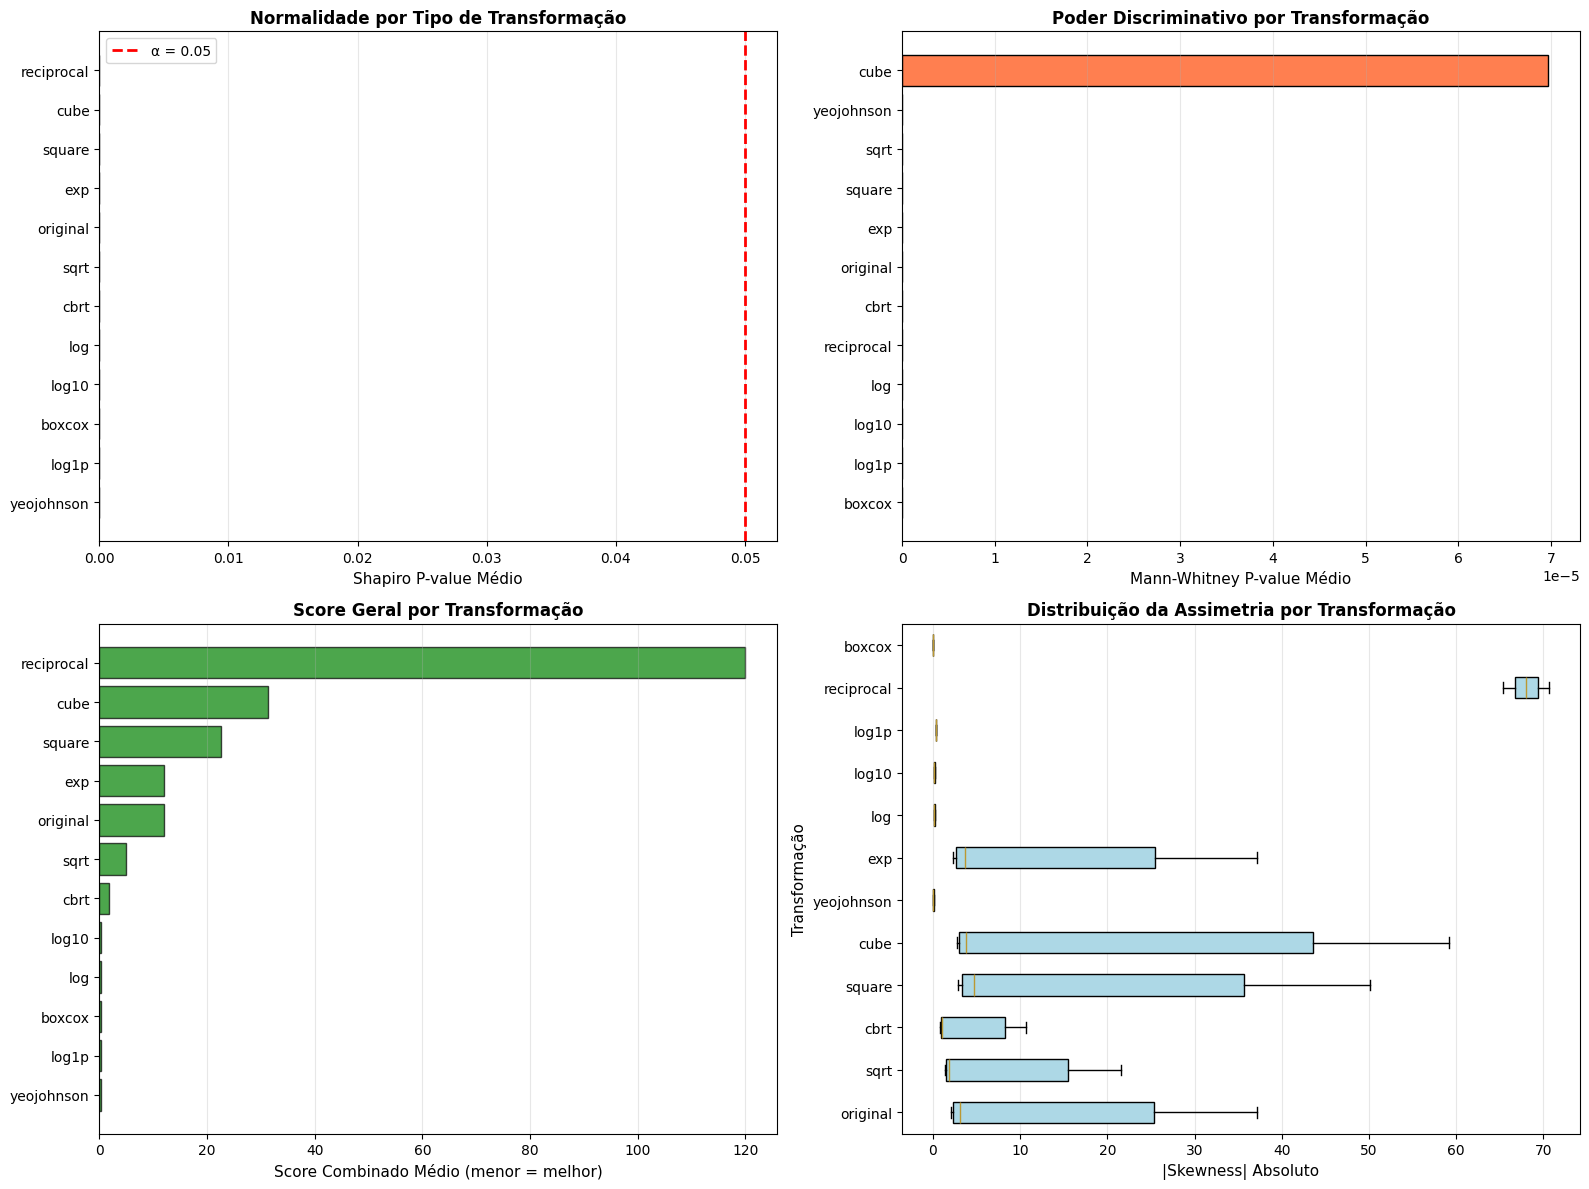

In [11]:
# Gráfico 1: Comparação de scores por tipo de transformação
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Shapiro p-value por transformação
trans_grouped = df_transformations.groupby('transformation')['shapiro_pvalue'].mean().sort_values(ascending=False)
axes[0, 0].barh(range(len(trans_grouped)), trans_grouped.values, color='steelblue', edgecolor='black')
axes[0, 0].set_yticks(range(len(trans_grouped)))
axes[0, 0].set_yticklabels(trans_grouped.index)
axes[0, 0].axvline(0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
axes[0, 0].set_xlabel('Shapiro P-value Médio', fontsize=11)
axes[0, 0].set_title('Normalidade por Tipo de Transformação', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3, axis='x')

# 2. Mann-Whitney p-value por transformação
trans_grouped_mw = df_transformations.groupby('transformation')['mannwhitney_pvalue'].mean().sort_values()
axes[0, 1].barh(range(len(trans_grouped_mw)), trans_grouped_mw.values, color='coral', edgecolor='black')
axes[0, 1].set_yticks(range(len(trans_grouped_mw)))
axes[0, 1].set_yticklabels(trans_grouped_mw.index)
axes[0, 1].set_xlabel('Mann-Whitney P-value Médio', fontsize=11)
axes[0, 1].set_title('Poder Discriminativo por Transformação', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='x')

# 3. Combined Score por transformação
trans_grouped_score = df_transformations.groupby('transformation')['combined_score'].mean().sort_values()
axes[1, 0].barh(range(len(trans_grouped_score)), trans_grouped_score.values, color='green', edgecolor='black', alpha=0.7)
axes[1, 0].set_yticks(range(len(trans_grouped_score)))
axes[1, 0].set_yticklabels(trans_grouped_score.index)
axes[1, 0].set_xlabel('Score Combinado Médio (menor = melhor)', fontsize=11)
axes[1, 0].set_title('Score Geral por Transformação', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='x')

# 4. Distribuição de Skewness por transformação
trans_types = df_transformations['transformation'].unique()
skew_data = [df_transformations[df_transformations['transformation'] == t]['skewness'].abs().dropna() 
             for t in trans_types]
bp = axes[1, 1].boxplot(skew_data, labels=trans_types, patch_artist=True, vert=False)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[1, 1].set_xlabel('|Skewness| Absoluto', fontsize=11)
axes[1, 1].set_ylabel('Transformação', fontsize=11)
axes[1, 1].set_title('Distribuição da Assimetria por Transformação', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

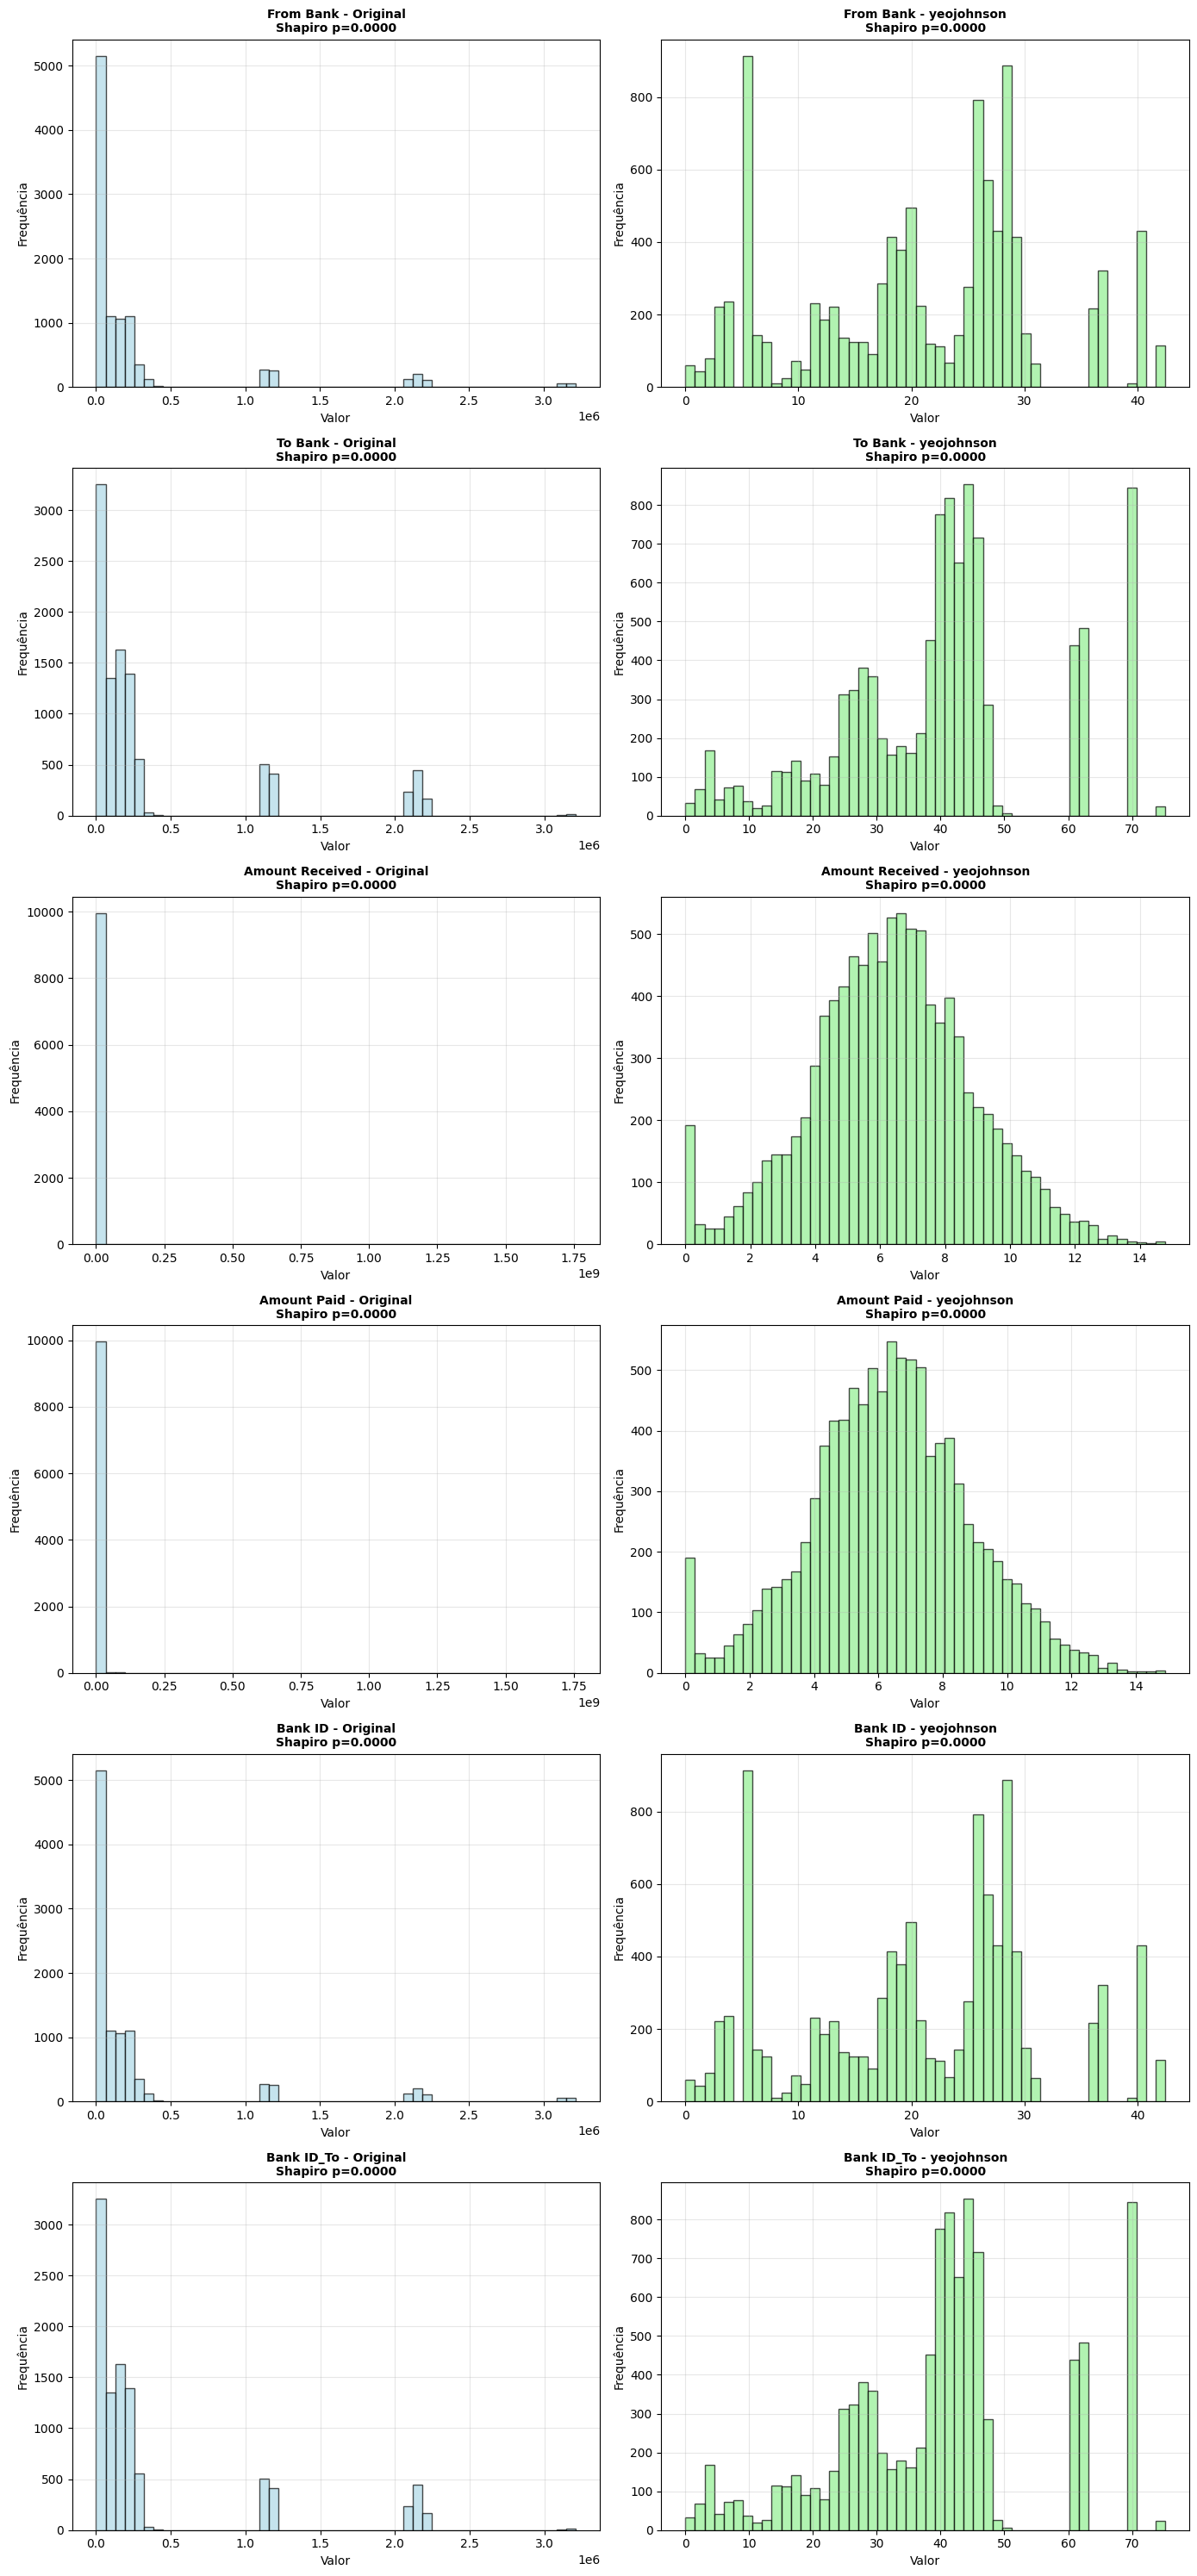

In [12]:
# Gráfico 2: Comparação por variável - Original vs Melhor
fig, axes = plt.subplots(len(feature_cols), 2, figsize=(14, 5*len(feature_cols)))

if len(feature_cols) == 1:
    axes = axes.reshape(1, -1)

for idx, variable in enumerate(feature_cols):
    var_results = df_transformations[df_transformations['variable'] == variable]
    
    original_row = var_results[var_results['transformation'] == 'original'].iloc[0]
    best_row = var_results.nsmallest(1, 'combined_score').iloc[0]
    
    # Dados originais vs transformados
    original_data = df_treino[variable].dropna()
    
    # Aplicar a melhor transformação
    best_trans_name = best_row['transformation']
    trans_dict = apply_transformations(df_treino[variable], variable)
    if best_trans_name in trans_dict:
        best_data = trans_dict[best_trans_name].dropna()
    else:
        best_data = original_data
    
    # Plot 1: Histograma Original
    axes[idx, 0].hist(original_data.sample(min(10000, len(original_data)), random_state=42), 
                      bins=50, edgecolor='black', color='lightblue', alpha=0.7)
    axes[idx, 0].set_title(f'{variable} - Original\nShapiro p={original_row["shapiro_pvalue"]:.4f}', 
                          fontsize=10, fontweight='bold')
    axes[idx, 0].set_xlabel('Valor')
    axes[idx, 0].set_ylabel('Frequência')
    axes[idx, 0].grid(alpha=0.3)
    
    # Plot 2: Histograma Melhor Transformação
    axes[idx, 1].hist(best_data.sample(min(10000, len(best_data)), random_state=42), 
                      bins=50, edgecolor='black', color='lightgreen', alpha=0.7)
    axes[idx, 1].set_title(f'{variable} - {best_trans_name}\nShapiro p={best_row["shapiro_pvalue"]:.4f}', 
                          fontsize=10, fontweight='bold')
    axes[idx, 1].set_xlabel('Valor')
    axes[idx, 1].set_ylabel('Frequência')
    axes[idx, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Seleção das Melhores Transformações

Identificando e salvando as melhores transformações para cada variável.

In [13]:
# Selecionar a melhor transformação para cada variável
best_transformations = df_transformations.loc[df_transformations.groupby('variable')['combined_score'].idxmin()]

print("="*80)
print("MELHORES TRANSFORMAÇÕES SELECIONADAS")
print("="*80)

for idx, row in best_transformations.iterrows():
    print(f"\n{row['variable']}:")
    print(f"  Transformação escolhida: {row['transformation']}")
    print(f"  Shapiro p-value: {row['shapiro_pvalue']:.6f}")
    print(f"  Mann-Whitney p-value: {row['mannwhitney_pvalue']:.6e}")
    print(f"  Skewness: {row['skewness']:.4f}")
    print(f"  Kurtosis: {row['kurtosis']:.4f}")
    print(f"  Combined Score: {row['combined_score']:.6f}")
    
    # Comparar com original
    original = df_transformations[(df_transformations['variable'] == row['variable']) & 
                                 (df_transformations['transformation'] == 'original')].iloc[0]
    improvement = ((original['combined_score'] - row['combined_score']) / original['combined_score'] * 100)
    print(f"  Melhoria sobre original: {improvement:.2f}%")

# Criar tabela resumo
print("\n" + "="*80)
print("TABELA RESUMO DAS MELHORES TRANSFORMAÇÕES")
print("="*80)
print(best_transformations[['variable', 'transformation', 'shapiro_pvalue', 'mannwhitney_pvalue', 
                            'skewness', 'combined_score']].to_string(index=False))

MELHORES TRANSFORMAÇÕES SELECIONADAS

Amount Paid:
  Transformação escolhida: yeojohnson
  Shapiro p-value: 0.000000
  Mann-Whitney p-value: 1.486588e-103
  Skewness: -0.0353
  Kurtosis: 0.1330
  Combined Score: 0.254208
  Melhoria sobre original: 99.36%

Amount Received:
  Transformação escolhida: yeojohnson
  Shapiro p-value: 0.000000
  Mann-Whitney p-value: 5.386952e-104
  Skewness: -0.0332
  Kurtosis: 0.1428
  Combined Score: 0.254399
  Melhoria sobre original: 99.18%

Bank ID:
  Transformação escolhida: yeojohnson
  Shapiro p-value: 0.000000
  Mann-Whitney p-value: 8.105012e-18
  Skewness: -0.1211
  Kurtosis: -0.7374
  Combined Score: 0.271463
  Melhoria sobre original: 52.48%

Bank ID_To:
  Transformação escolhida: yeojohnson
  Shapiro p-value: 0.000000
  Mann-Whitney p-value: 6.881724e-12
  Skewness: -0.0065
  Kurtosis: -0.0496
  Combined Score: 0.251402
  Melhoria sobre original: 33.45%

From Bank:
  Transformação escolhida: yeojohnson
  Shapiro p-value: 0.000000
  Mann-Whitney

## 8. Critérios de Decisão

Análise dos critérios para escolha das transformações.

In [14]:
print("="*80)
print("CRITÉRIOS DE DECISÃO E RECOMENDAÇÕES")
print("="*80)

print("\n1. CRITÉRIOS UTILIZADOS:")
print("-" * 80)
print("   a) Normalidade (Shapiro-Wilk p-value): quanto MAIOR, melhor")
print("      - p >= 0.05: dados seguem distribuição normal")
print("   b) Poder Discriminativo (Mann-Whitney p-value): quanto MENOR, melhor")
print("      - p < 0.05: grupos são significativamente diferentes")
print("   c) Assimetria (Skewness): quanto mais PRÓXIMO de 0, melhor")
print("      - |skew| < 0.5: distribuição aproximadamente simétrica")
print("   d) Curtose (Kurtosis): quanto mais PRÓXIMO de 0, melhor")
print("      - Distribuição normal tem curtose ~0")

print("\n2. SCORE COMBINADO:")
print("-" * 80)
print("   Score = (1-shapiro_p + mannwhitney_p + |skew|/10 + |kurt|/10) / 4")
print("   Quanto MENOR o score, melhor a transformação")

print("\n3. ANÁLISE DAS MELHORES TRANSFORMAÇÕES:")
print("-" * 80)

for variable in feature_cols:
    best = best_transformations[best_transformations['variable'] == variable].iloc[0]
    original = df_transformations[(df_transformations['variable'] == variable) & 
                                 (df_transformations['transformation'] == 'original')].iloc[0]
    
    print(f"\n{variable}:")
    print(f"  Transformação escolhida: {best['transformation']}")
    
    # Análise de normalidade
    if best['shapiro_pvalue'] >= 0.05:
        print(f"  ✓ Normalidade: MELHOROU (p={best['shapiro_pvalue']:.4f} vs {original['shapiro_pvalue']:.4f})")
    elif best['shapiro_pvalue'] > original['shapiro_pvalue']:
        print(f"  ~ Normalidade: MELHOROU PARCIALMENTE (p={best['shapiro_pvalue']:.4f} vs {original['shapiro_pvalue']:.4f})")
    else:
        print(f"  ✗ Normalidade: NÃO MELHOROU (p={best['shapiro_pvalue']:.4f} vs {original['shapiro_pvalue']:.4f})")
    
    # Análise de discriminação
    if best['mannwhitney_pvalue'] < original['mannwhitney_pvalue']:
        print(f"  ✓ Discriminação: MELHOROU (p={best['mannwhitney_pvalue']:.2e} vs {original['mannwhitney_pvalue']:.2e})")
    else:
        print(f"  ✗ Discriminação: PIOROU (p={best['mannwhitney_pvalue']:.2e} vs {original['mannwhitney_pvalue']:.2e})")
    
    # Análise de assimetria
    if abs(best['skewness']) < abs(original['skewness']):
        print(f"  ✓ Assimetria: MELHOROU ({best['skewness']:.4f} vs {original['skewness']:.4f})")
    else:
        print(f"  ✗ Assimetria: PIOROU ({best['skewness']:.4f} vs {original['skewness']:.4f})")

print("\n" + "="*80)

CRITÉRIOS DE DECISÃO E RECOMENDAÇÕES

1. CRITÉRIOS UTILIZADOS:
--------------------------------------------------------------------------------
   a) Normalidade (Shapiro-Wilk p-value): quanto MAIOR, melhor
      - p >= 0.05: dados seguem distribuição normal
   b) Poder Discriminativo (Mann-Whitney p-value): quanto MENOR, melhor
      - p < 0.05: grupos são significativamente diferentes
   c) Assimetria (Skewness): quanto mais PRÓXIMO de 0, melhor
      - |skew| < 0.5: distribuição aproximadamente simétrica
   d) Curtose (Kurtosis): quanto mais PRÓXIMO de 0, melhor
      - Distribuição normal tem curtose ~0

2. SCORE COMBINADO:
--------------------------------------------------------------------------------
   Score = (1-shapiro_p + mannwhitney_p + |skew|/10 + |kurt|/10) / 4
   Quanto MENOR o score, melhor a transformação

3. ANÁLISE DAS MELHORES TRANSFORMAÇÕES:
--------------------------------------------------------------------------------

From Bank:
  Transformação escolhida: yeojo

## 9. Exportar Resultados

Salvando os resultados completos e as melhores transformações.

In [15]:
# Exportar resultados completos
output_path_full = '../data/processed/transformation_analysis_full.csv'
df_transformations.to_csv(output_path_full, index=False)
print(f"✓ Resultados completos salvos em: {output_path_full}")

# Exportar melhores transformações
output_path_best = '../data/processed/best_transformations.csv'
best_transformations.to_csv(output_path_best, index=False)
print(f"✓ Melhores transformações salvas em: {output_path_best}")

# Criar resumo executivo
print("\n" + "="*80)
print("RESUMO EXECUTIVO - TRANSFORMAÇÕES DE VARIÁVEIS")
print("="*80)

print(f"\n1. PROCESSAMENTO:")
print(f"   - Total de variáveis analisadas: {len(feature_cols)}")
print(f"   - Tipos de transformações testadas: {df_transformations['transformation'].nunique()}")
print(f"   - Total de transformações avaliadas: {len(df_transformations)}")

print(f"\n2. RESULTADOS GERAIS:")
# Contar quantas vezes cada tipo de transformação foi escolhido como melhor
best_trans_counts = best_transformations['transformation'].value_counts()
print(f"   Distribuição das melhores transformações:")
for trans, count in best_trans_counts.items():
    print(f"   - {trans}: {count} vez(es)")

print(f"\n3. MELHORIA MÉDIA:")
for variable in feature_cols:
    best = best_transformations[best_transformations['variable'] == variable].iloc[0]
    original = df_transformations[(df_transformations['variable'] == variable) & 
                                 (df_transformations['transformation'] == 'original')].iloc[0]
    
    improvement = ((original['combined_score'] - best['combined_score']) / original['combined_score'] * 100)
    print(f"   - {variable}: {improvement:.2f}% de melhoria")

print(f"\n4. RECOMENDAÇÕES:")
print(f"   ✓ Aplicar as transformações selecionadas antes da modelagem")
print(f"   ✓ Variáveis transformadas terão melhor comportamento em modelos paramétricos")
print(f"   ✓ Considerar usar as transformações para feature engineering")

print("\n" + "="*80)

# Criar DataFrame de resumo
summary_df = pd.DataFrame({
    'Variável': feature_cols,
    'Transformação Original': ['Nenhuma'] * len(feature_cols),
    'Melhor Transformação': [best_transformations[best_transformations['variable'] == v]['transformation'].values[0] 
                             for v in feature_cols],
    'Score Original': [df_transformations[(df_transformations['variable'] == v) & 
                                          (df_transformations['transformation'] == 'original')]['combined_score'].values[0] 
                      for v in feature_cols],
    'Score Transformado': [best_transformations[best_transformations['variable'] == v]['combined_score'].values[0] 
                          for v in feature_cols],
    'Melhoria (%)': [((df_transformations[(df_transformations['variable'] == v) & 
                                          (df_transformations['transformation'] == 'original')]['combined_score'].values[0] -
                      best_transformations[best_transformations['variable'] == v]['combined_score'].values[0]) /
                     df_transformations[(df_transformations['variable'] == v) & 
                                       (df_transformations['transformation'] == 'original')]['combined_score'].values[0] * 100)
                    for v in feature_cols]
})

print("\nTabela Resumo:")
print(summary_df.to_string(index=False))

# Salvar resumo
summary_path = '../data/processed/transformation_summary.csv'
summary_df.to_csv(summary_path, index=False)
print(f"\n✓ Resumo salvo em: {summary_path}")

✓ Resultados completos salvos em: ../data/processed/transformation_analysis_full.csv
✓ Melhores transformações salvas em: ../data/processed/best_transformations.csv

RESUMO EXECUTIVO - TRANSFORMAÇÕES DE VARIÁVEIS

1. PROCESSAMENTO:
   - Total de variáveis analisadas: 6
   - Tipos de transformações testadas: 12
   - Total de transformações avaliadas: 52

2. RESULTADOS GERAIS:
   Distribuição das melhores transformações:
   - yeojohnson: 6 vez(es)

3. MELHORIA MÉDIA:
   - From Bank: 52.48% de melhoria
   - To Bank: 33.45% de melhoria
   - Amount Received: 99.18% de melhoria
   - Amount Paid: 99.36% de melhoria
   - Bank ID: 52.48% de melhoria
   - Bank ID_To: 33.45% de melhoria

4. RECOMENDAÇÕES:
   ✓ Aplicar as transformações selecionadas antes da modelagem
   ✓ Variáveis transformadas terão melhor comportamento em modelos paramétricos
   ✓ Considerar usar as transformações para feature engineering


Tabela Resumo:
       Variável Transformação Original Melhor Transformação  Score Origi